## **Cycle GAN**

*Descriptions and images from this notebook are taken from the original paper* [*Unpaired Image-to-Image Translation
using Cycle-Consistent Adversarial Networks*](https://arxiv.org/pdf/1703.10593).

In the context of image-to-image translations, there are many cases when we would want to map images from one category to another, and there are no datasets with a direct mapping between the two categories; if they exist, they cannot be large enough to build a robust model. To solve this issue, consistent-cycle GANs were introduced to capture the special characteristics of one image collection and figure out how these characteristics could be translated into other image collections, *all in the absence of any paired training examples*.

| 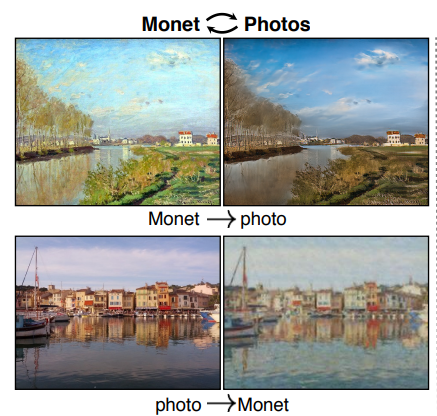 | 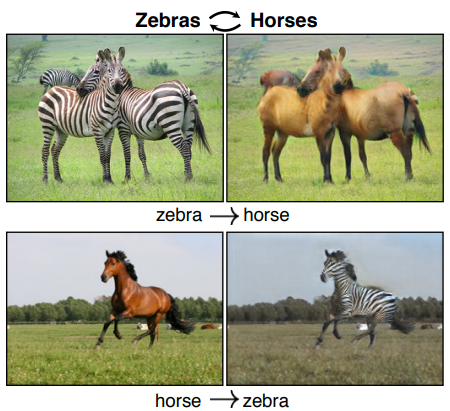 |
|:---:|:---:|

The goal is to learn mapping functions between two domains $X$ and $Y$ given training samples $x_i, i=1..N$ where $x_i \in X$ and $y_j, j=1..M$ where $y_j \in Y$. Distributions are denoted as $x \sim p_data(x)$ and $y \sim p_data(y)$. The model includes:
- two mappings: $G:X \to Y$ and $F:Y \to X$
- two discriminators: $D_X$ to distinguish between $x$ and $F(y)$ and $D_Y$ to distinguish between $y$ and $G(x)$. 

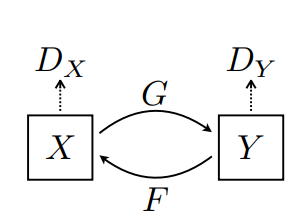

**Adversarial Loss**: an adversarial loss is computed for both mapping functions. For the mapping function $G:X \to Y$ and its discriminator $D_Y$ it is expressed as:

$$ \mathcal{L}_{GAN}(G, D_Y, X, Y) = \mathbb{E}_{y \sim p_{data}(y)} [log D_Y(y)] + \mathbb{E}_{x \sim p_{data}(x)} [log(1 - D_Y(G(x)))] $$

**Cycle Consistency Loss**: a network can map the *same set of input images* to any *random permutation* of images in the *target domain*, where any of the learned mappings can induce an output distribution that matches the target distribution. There is no guarantee that a function can map an individual input $x_i$ to a desired output $y_i$. This is why it is argued that the learned mapping functions should be cycle-consistent.

| 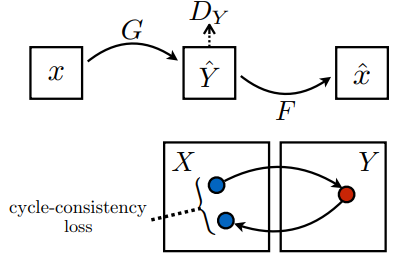 | 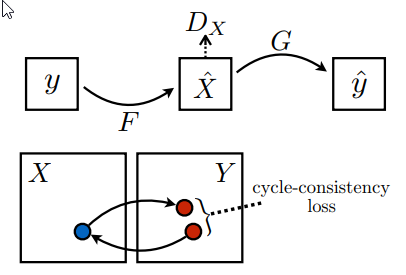 |
|:---:|:---:|

- for each image $x \in X$, the image translation cycle should be able to bring $x$ back to the original image, i.e., $x \to G(x) \to F(G(x)) \approx x$ = *forward cycle consistency*
- for each images $y \in Y$, $G$ and $F$ should also satisfy this condition, i.e., $y \to F(y) \to G(F(y)) \approx y$: *backward cycle consistency*

$$ \mathcal{L}_{cyc}(G, F) = \mathbb{E}_{x \sim p_{data}(x)} [\| F(G(x)) - x \|_1] + \mathbb{E}_{y \sim p_{data}(y)} [\| G(F(y)) - y \|_1] $$

**Final Loss**: the combined loss can be viewed as training two *"autoencodes"*; we learn one autoencode $F \circ G : X \to X$ jointly with another $G \circ F : Y \to Y$.

$$ \mathcal{L}(G, D, D_X, D_Y) = \mathcal{L}_{GAN}(G, D_Y, X, Y) + \mathcal{L}_{GAN}(F, D_X, Y, X) + \lambda \mathcal{L}_{cyc}(G, F), $$

where $\lambda$ controls the relative importance of the two objectives. The aim is to solve:

$$
G^*, F^* = \arg \min_{G, F} \max_{D_X, D_Y} \mathcal{L}(G, F, D_X, D_Y).
$$

In [1]:
!pip install datasets torch torchvision pillow matplotlib

In [4]:
import sys
!{sys.executable} -m pip install datasets
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matpl

In [5]:
import io
import itertools
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np

from datasets import load_dataset
from PIL import Image
from torch.utils.data import Dataset

## **Inputs**

In [6]:
workers = 2
batch_size = 5
image_size = 256
nc = 3
nz = 100
ngf = 64
ndf = 64
num_epochs = 5
lr = 0.0001
beta1 = 0.5
ngpu = 1

## **Dataset**

In [7]:
ds = load_dataset("huggan/vangogh2photo")

transform = transforms.Compose([
    transforms.ToTensor(),  
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])

def from_bytes_to_torch(b: bytes) -> torch.Tensor:
    img = Image.open(io.BytesIO(b))
    img = img.convert("RGB")
    img = transform(img)

    return img

Repo card metadata block was not found. Setting CardData to empty.


In [8]:
train_A = torch.stack([from_bytes_to_torch(b["bytes"]) for b in ds["train"]["imageA"]])
train_B = torch.stack([from_bytes_to_torch(b["bytes"]) for b in ds["train"]["imageB"]])
test_A = torch.stack([from_bytes_to_torch(b["bytes"]) for b in ds["test"]["imageA"]])
test_B = torch.stack([from_bytes_to_torch(b["bytes"]) for b in ds["test"]["imageB"]])

print(f"Train Samples: A = {train_A.shape[0]}, B = {train_B.shape[0]}")
print(f"Test Samples: A = {test_A.shape[0]}, B = {test_B.shape[0]}")

Train Samples: A = 6287, B = 6287
Test Samples: A = 751, B = 751


In [9]:
class ImageDataset(Dataset):
    def __init__(self, A: torch.Tensor, B: torch.Tensor):
        self.A = A
        self.B = B

    def __getitem__(self, index):
        return self.A[index], self.B[index]

    def __len__(self):
        return len(self.A)

In [10]:
train_dataloader = torch.utils.data.DataLoader(
    ImageDataset(train_A, train_B),
    batch_size=batch_size,
    shuffle=True,
)

test_dataloader = torch.utils.data.DataLoader(
    ImageDataset(test_A, test_B),
    batch_size=batch_size,
    shuffle=True,
)

## **Generator**

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}!")

Working on cuda!


In [11]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResidualBlock, self).__init__()

        self.block = nn.Sequential(
            # padding, keep the image size constant after next Conv2d
            nn.ReflectionPad2d(1), 
            nn.Conv2d(in_channels, in_channels, 3),
            nn.InstanceNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_channels, in_channels, 3),
            nn.InstanceNorm2d(in_channels)
        )
    
    def forward(self, x):
        return x + self.block(x)

In [30]:
class Generator(nn.Module):
    def __init__(self, in_channels: int, n_residual_blocks: int = 9):
        super(Generator, self).__init__()
        
        out_channels = 64
        # input: (3, 256, 256) -> (64, 256, 256)
        self.feature_extraction = nn.Sequential(
            # padding, keep the image size constant after next Conv2d
            nn.ReflectionPad2d(in_channels),
            nn.Conv2d(in_channels, out_channels, 2 * in_channels + 1),
            nn.InstanceNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
        channels = out_channels

        # downsampling: 64*256*256 -> 128*128*128 -> 256*64*64 
        self.downsampling = []
        for _ in range(2):
            out_channels = channels * 2
            self.downsampling += [
                nn.Conv2d(channels, out_channels, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ] 
            channels = out_channels
        self.downsampling = nn.Sequential(*self.downsampling)

        # transformation using resnet
        self.resnet = [ResidualBlock(channels) for _ in range(n_residual_blocks)]
        self.resnet = nn.Sequential(*self.resnet)

        # upsampling: 256*64*64 -> 128*128*128 -> 64*256*256
        self.upsampling = []
        for _ in range(2):
            out_channels = channels // 2
            self.upsampling += [
                # bilinear interpolation
                nn.Upsample(scale_factor=2),
                nn.Conv2d(channels, out_channels, kernel_size=3, stride=1, padding=1),
                nn.InstanceNorm2d(out_channels),
                nn.ReLU(inplace=True),
            ]
            channels = out_channels
        self.upsampling = nn.Sequential(*self.upsampling)

        # output layer
        self.out = nn.Sequential(
            nn.ReflectionPad2d(in_channels),
            nn.Conv2d(channels, in_channels, 2 * in_channels + 1),
            nn.Tanh()
        )


    def forward(self, x):
        x = self.feature_extraction(x)
        x = self.downsampling(x)
        x = self.resnet(x)
        x = self.upsampling(x)
        x = self.out(x)

        return x
    
generator_A_to_B = Generator(in_channels=3).to(device)
generator_B_to_A = Generator(in_channels=3).to(device)

print(generator_A_to_B)

Generator(
  (feature_extraction): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1))
    (2): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): ReLU(inplace=True)
  )
  (downsampling): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (5): ReLU(inplace=True)
  )
  (resnet): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): ReflectionPad2d((1, 1, 1, 1))
        (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1))
        (2): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (3): Re

## **Discriminator**

In [31]:
class Discriminator(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        
        self.net = nn.Sequential(
            *self.block(in_channels, 64, normalize=False),  # 3*256*256  -> 64*128*128
            *self.block(64, 128),                           # 64*128*128 -> 128*64*64
            *self.block(128, 256),                          # 128*64*64  -> 256*32*32
            *self.block(256, 512),                          # 256*32*32  -> 512*16*16

            nn.ZeroPad2d((1, 0, 1, 0)), # padding left and top 512*16*16 -> 512*17*17
            nn.Conv2d(512, 1, kernel_size=4, padding=1) # 512*17*17 -> 1*16*16
        )
        self.scale_factor = 16

    @staticmethod
    def block(in_channels: int, out_channels: int, normalize=True):
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)]
        if normalize:
            layers.append(nn.InstanceNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))

        return layers

    def forward(self, x):
        return self.net(x)
    
discriminator_B = Discriminator(in_channels=3).to(device)
discriminator_A = Discriminator(in_channels=3).to(device)

print(discriminator_B)

Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): ZeroPad2d((1, 0, 1, 0))
    (12): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)


## **Training**

In [25]:
# the cross entropy was subtituted for MSE, becase it was more stable
criterion_GAN = nn.MSELoss().to(device)
# loss for reconstruction
criterion_cycle = nn.L1Loss().to(device)
# this loss was added in the original paper for painting generation
criterion_identity = nn.L1Loss().to(device)

In [16]:
optimizer_G = torch.optim.Adam(
    itertools.chain(generator_A_to_B.parameters(), generator_B_to_A.parameters()),
    lr=lr,
    betas=(beta1, 0.999),
)

optimizer_D_A = torch.optim.Adam(
    discriminator_A.parameters(),
    lr=lr,
    betas=(beta1, 0.999),
)

optimizer_D_B = torch.optim.Adam(
    discriminator_B.parameters(),
    lr=lr,
    betas=(beta1, 0.999),
)

In [17]:
iters = 0
generator_A_evolution = []

G_A_B_losses = []
G_B_A_losses = []
A_cycle_losses = []
B_cycle_losses = []
A_identity_losses = []
B_identity_losses = []
D_A_losses = []
D_B_losses = []

print("Starting Training Loop...")

for epoch in range(num_epochs):
    for i, (real_A, real_B) in enumerate(train_dataloader):
        real_A, real_B = real_A.to(device), real_B.to(device)
        
        # compute the output shape of the discriminator based on its scale factor
        out_shape = [real_A.size(0), 1, real_A.size(2) // discriminator_A.scale_factor, real_A.size(3) // discriminator_A.scale_factor]
        real_labels = torch.ones(out_shape).to(device)
        fake_labels = torch.zeros(out_shape).to(device)

        ####################
        # Update G network #
        ####################
        generator_A_to_B.train()
        generator_B_to_A.train()
        optimizer_G.zero_grad()

        fake_B = generator_A_to_B(real_A)
        fake_A = generator_B_to_A(real_B)

        # identity loss
        loss_identity_A = criterion_identity(real_A, fake_B)
        loss_identity_B = criterion_identity(real_B, fake_A)
        loss_identity = (loss_identity_A + loss_identity_B) / 2

        # GAN loss
        loss_GAN_A_to_B = criterion_GAN(discriminator_B(fake_B), real_labels)
        loss_GAN_B_to_A = criterion_GAN(discriminator_A(fake_A), real_labels)
        loss_GAN = (loss_GAN_A_to_B + loss_GAN_B_to_A) / 2

        # cycle loss
        translated_A = generator_B_to_A(fake_B)
        translated_B = generator_A_to_B(fake_A)
        loss_cycle_A = criterion_cycle(translated_A, real_A)
        loss_cycle_B = criterion_cycle(translated_B, real_B)
        loss_cycle = (loss_cycle_A + loss_cycle_B) / 2

        # total loss
        loss_G = loss_GAN + 5.0 * loss_identity + 10.0 * loss_cycle
        loss_G.backward()
        optimizer_G.step()

        ##########################
        # Update Discriminator A #
        ##########################

        optimizer_D_A.zero_grad()

        loss_D_A_real = criterion_GAN(discriminator_A(real_A), real_labels)
        loss_D_A_fake = criterion_GAN(discriminator_A(fake_A.detach()), fake_labels)
        loss_D_A = (loss_D_A_real + loss_D_A_fake) / 2
        
        loss_D_A.backward()
        optimizer_D_A.step()

        ##########################
        # Update Discriminator B #
        ##########################

        optimizer_D_B.zero_grad()

        loss_D_B_real = criterion_GAN(discriminator_B(real_B), real_labels)
        loss_D_B_fake = criterion_GAN(discriminator_B(fake_B.detach()), fake_labels)
        loss_D_B = (loss_D_B_real + loss_D_B_fake) / 2

        loss_D_B.backward()
        optimizer_D_B.step()

        # save losses for plotting
        G_A_B_losses.append(loss_GAN_A_to_B.item())
        G_B_A_losses.append(loss_GAN_B_to_A.item())
        A_cycle_losses.append(loss_cycle_A.item())
        B_cycle_losses.append(loss_cycle_B.item())
        A_identity_losses.append(loss_identity_A.item())
        B_identity_losses.append(loss_identity_B.item())
        D_A_losses.append(loss_D_A.item())
        D_B_losses.append(loss_D_B.item())

        if i % 100 == 0:
            print(f"[{epoch}/{num_epochs}] [{i}/{len(train_dataloader)}] Loss_G: {loss_G.item():.4f} Loss_D_A: {loss_D_A.item():.4f} Loss_D_B: {loss_D_B.item():.4f}")

        if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(train_dataloader) - 1)):
            with torch.no_grad():
                generated_samples = generator_A_to_B(test_A[:20].to(device)).detach().cpu()
                generator_A_evolution.append(vutils.make_grid(generated_samples, padding=2, normalize=True))

        iters += 1

torch.save(generator_A_to_B.state_dict(), "generator_A_to_B.pth")
torch.save(generator_B_to_A.state_dict(), "generator_B_to_A.pth")
torch.save(discriminator_A.state_dict(), "discriminator_A.pth")
torch.save(discriminator_B.state_dict(), "discriminator_B.pth")

Starting Training Loop...
[0/5] [0/1258] Loss_G: 8.7578 Loss_D_A: 0.7001 Loss_D_B: 0.4214
[0/5] [100/1258] Loss_G: 5.0852 Loss_D_A: 0.1730 Loss_D_B: 0.2016
[0/5] [200/1258] Loss_G: 4.1211 Loss_D_A: 0.1513 Loss_D_B: 0.2175
[0/5] [300/1258] Loss_G: 4.0390 Loss_D_A: 0.1388 Loss_D_B: 0.2337
[0/5] [400/1258] Loss_G: 4.3183 Loss_D_A: 0.0826 Loss_D_B: 0.0568
[0/5] [500/1258] Loss_G: 4.3624 Loss_D_A: 0.1163 Loss_D_B: 0.1493
[0/5] [600/1258] Loss_G: 4.4615 Loss_D_A: 0.1275 Loss_D_B: 0.1132
[0/5] [700/1258] Loss_G: 3.8511 Loss_D_A: 0.1916 Loss_D_B: 0.1337
[0/5] [800/1258] Loss_G: 3.7783 Loss_D_A: 0.1389 Loss_D_B: 0.0973
[0/5] [900/1258] Loss_G: 3.6017 Loss_D_A: 0.0790 Loss_D_B: 0.2245
[0/5] [1000/1258] Loss_G: 4.0698 Loss_D_A: 0.1802 Loss_D_B: 0.1782
[0/5] [1100/1258] Loss_G: 4.3620 Loss_D_A: 0.1336 Loss_D_B: 0.1090
[0/5] [1200/1258] Loss_G: 3.3622 Loss_D_A: 0.2611 Loss_D_B: 0.2229
[1/5] [0/1258] Loss_G: 4.1059 Loss_D_A: 0.1900 Loss_D_B: 0.0725
[1/5] [100/1258] Loss_G: 3.3716 Loss_D_A: 0.0778 Lo

In [32]:
generator_A_to_B.load_state_dict(torch.load('generator_A_to_B.pth', weights_only=True))
generator_B_to_A.load_state_dict(torch.load('generator_B_to_A.pth', weights_only=True))
discriminator_A.load_state_dict(torch.load('discriminator_A.pth', weights_only=True))
discriminator_B.load_state_dict(torch.load('discriminator_B.pth', weights_only=True))

<All keys matched successfully>

In [39]:
test_A, test_B = next(iter(test_dataloader))
generator_A_to_B.eval()
generated_B = generator_A_to_B(test_A.to(device))
generator_B_to_A.eval()
generated_A = generator_B_to_A(test_B.to(device))

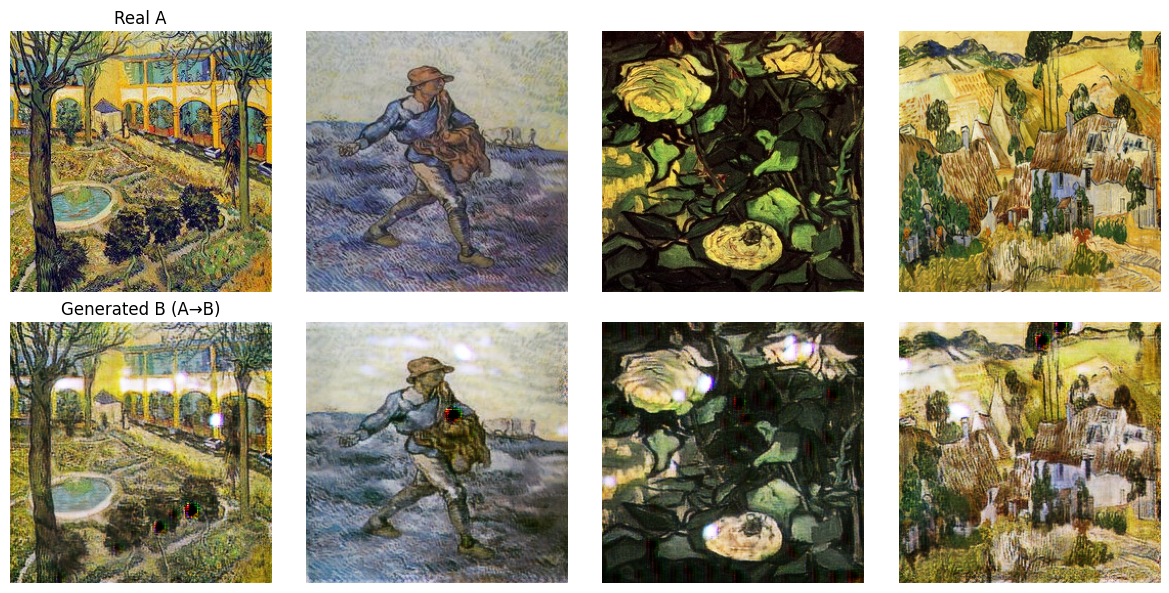

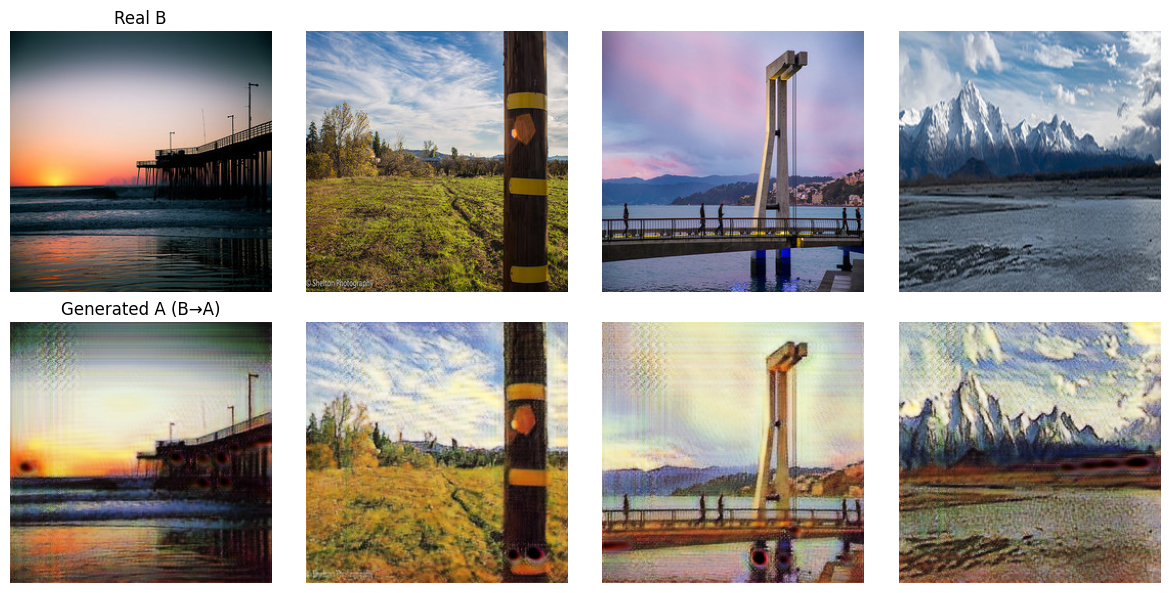

In [40]:
def show_side_by_side(real, generated, title_real, title_gen, n=4):
    # clamp and move to cpu
    real = real[:n].cpu().detach()
    generated = generated[:n].cpu().detach()

    # denormalize from [-1, 1] to [0, 1] (if you normalized with mean=0.5, std=0.5)
    real = (real * 0.5 + 0.5).clamp(0, 1)
    generated = (generated * 0.5 + 0.5).clamp(0, 1)

    fig, axes = plt.subplots(2, n, figsize=(n * 3, 6))
    for i in range(n):
        axes[0, i].imshow(np.transpose(real[i].numpy(), (1, 2, 0)))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title(title_real, fontsize=12)

        axes[1, i].imshow(np.transpose(generated[i].numpy(), (1, 2, 0)))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title(title_gen, fontsize=12)

    plt.tight_layout()
    plt.show()

show_side_by_side(test_A, generated_B, "Real A", "Generated B (A→B)")
show_side_by_side(test_B, generated_A, "Real B", "Generated A (B→A)")